In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

In [3]:
import pandas as pd
data = {
    "mpg": [18, 15, 24, 27, 25],
    "cylinders": [8, 8, 4, 4, 4],
    "horsepower": [130, 165, 95, 88, 87],
    "weight": [3504, 3693, 2372, 2130, 2672]
}
df = pd.DataFrame(data)
df.to_csv("auto-mpg_dataset.csv", index=False)
print("CSV file created successfully!")

CSV file created successfully!


In [4]:
df = pd.read_csv("auto-mpg_dataset.csv")
df.head()

,mpg,cylinders,horsepower,weight
0,18,8,130,3504
1,15,8,165,3693
2,24,4,95,2372
3,27,4,88,2130
4,25,4,87,2672


In [5]:
df.shape

(5, 4)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   mpg         5 non-null      int64
 1   cylinders   5 non-null      int64
 2   horsepower  5 non-null      int64
 3   weight      5 non-null      int64
dtypes: int64(4)
memory usage: 292.0 bytes


In [7]:
df.isnull().sum()

,0
mpg,0
cylinders,0
horsepower,0
weight,0


In [8]:
df['horsepower'].unique()

array([130, 165,  95,  88,  87])

In [11]:
df['horsepower'] = df['horsepower'].replace('?', np.nan)
print(df['horsepower'].unique())

[130 165  95  88  87]


In [12]:
df['horsepower'].fillna(df['horsepower'].median(), inplace=True)

/tmp/ipykernel_14026/1826784813.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['horsepower'].fillna(df['horsepower'].median(), inplace=True)


In [13]:
df.corr()

,mpg,cylinders,horsepower,weight
mpg,1.000000,-0.954374,-0.973866,-0.968325
cylinders,-0.954374,1.000000,0.926897,0.955843
horsepower,-0.973866,0.926897,1.000000,0.916723
weight,-0.968325,0.955843,0.916723,1.000000


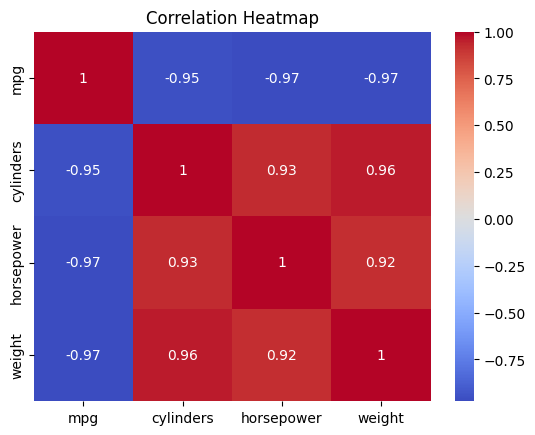

In [15]:
import seaborn as sns
sns.heatmap(
df.corr(),annot = True, cmap = 'coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [17]:
y = df['mpg']
x = df.drop('mpg', axis=1)
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [18]:
lr = LinearRegression()
lr.fit(x_train, y_train)

LinearRegression()

In [20]:
y_prediction = lr.predict(x_test)
print(y_prediction)

[7.30054509]


In [21]:
r2 = r2_score(y_test, y_prediction)
print("R-squared:", r2)

R-squared: nan


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_regression.py:1266: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


In [22]:
rmse = np.sqrt(mean_squared_error(y_test, y_prediction))
print("RMSE:", rmse)

RMSE: 7.699454905847325


In [23]:
mae = mean_absolute_error(y_test, y_prediction)
print("MAE:", mae)

MAE: 7.699454905847325


In [30]:
coef_df = pd.DataFrame({
     'Feature': x.columns,
     'Coefficient': lr.coef_
    })
coef_df.sort_values(by='Coefficient', ascending=False, inplace=True)
print(coef_df)


      Feature  Coefficient
0   cylinders     2.167864
2      weight    -0.004212
1  horsepower    -0.282953


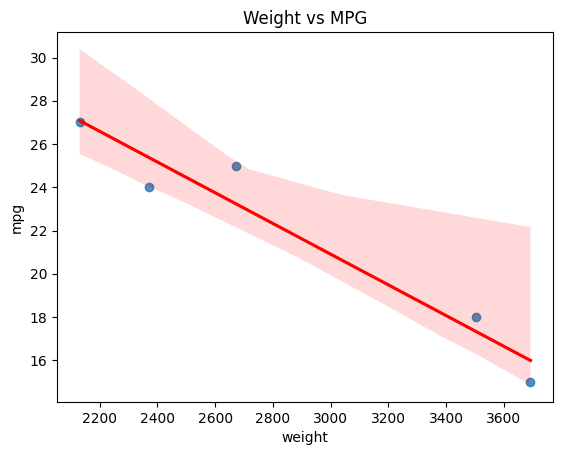

In [31]:
sns.regplot(
    x='weight',
    y='mpg',
    data=df,
    line_kws={'color':'red'}
)

plt.title("Weight vs MPG")
plt.show()

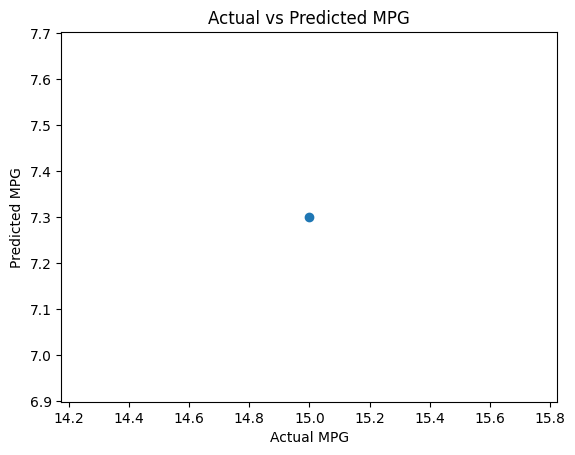

In [34]:
plt.scatter(
    y_test,
    y_prediction
)

plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")

plt.title(
    "Actual vs Predicted MPG"
)

plt.show()

In [36]:
residuals = y_test - y_prediction

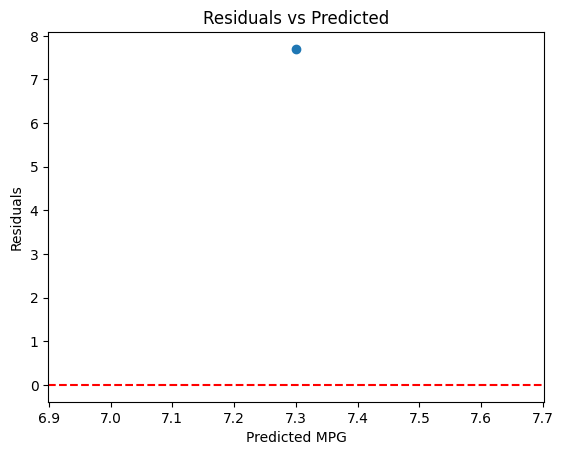

In [38]:
plt.scatter(
    y_prediction,
    residuals
)

plt.axhline(
    y=0,
    color='red',
    linestyle='--'
)

plt.xlabel("Predicted MPG")
plt.ylabel("Residuals")

plt.title(
    "Residuals vs Predicted"
)
plt.show()

In [39]:
print("R2 Score :", r2)
print("MAE :", mae)
print("RMSE :", rmse)

R2 Score : nan
MAE : 7.699454905847325
RMSE : 7.699454905847325
